# Week 6 Bonus — Real Data Practice: German Credit Dataset
**Dataset:** Statlog German Credit (`credit-g`), fetched via scikit-learn's
OpenML connector. 1,000 loan applications, 20 features, binary target
`class` (`good` / `bad`), classes imbalanced ~70/30.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, brier_score_loss,
)
from sklearn.calibration import calibration_curve, CalibrationDisplay
from sklearn.base import clone
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
RANDOM_STATE = 42  
np.random.seed(RANDOM_STATE)

In [2]:
Path("graphs").mkdir(parents=True, exist_ok=True)

## 2. Load the data

Fetched once from OpenML and cached locally by scikit-learn afterwards.

In [3]:
credit = fetch_openml(name="credit-g", version=1, as_frame=True, parser="auto")
df = credit.frame

print(df.shape)
df.head()

(1000, 21)


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,4,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,2,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,3,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,4,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,4,no known property,53,none,for free,2,skilled,2,none,yes,bad


## 3. Diagnose

Same habit as every dataset this week: shape, dtypes, summary stats, class
balance, and a look at every categorical column's value counts. Nothing here
is planted -- the job is describing what's genuinely there, not hunting for
a bug.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   checking_status         1000 non-null   category
 1   duration                1000 non-null   int64   
 2   credit_history          1000 non-null   category
 3   purpose                 1000 non-null   category
 4   credit_amount           1000 non-null   int64   
 5   savings_status          1000 non-null   category
 6   employment              1000 non-null   category
 7   installment_commitment  1000 non-null   int64   
 8   personal_status         1000 non-null   category
 9   other_parties           1000 non-null   category
 10  residence_since         1000 non-null   int64   
 11  property_magnitude      1000 non-null   category
 12  age                     1000 non-null   int64   
 13  other_payment_plans     1000 non-null   category
 14  housing                 1000 non-nul

In [5]:
df.describe()

,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


In [6]:
df.describe(include="number").T

,count,mean,std,min,25%,50%,75%,max
duration,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
credit_amount,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
installment_commitment,1000.0,2.973,1.118715,1.0,2.0,3.0,4.00,4.0
residence_since,1000.0,2.845,1.103718,1.0,2.0,3.0,4.00,4.0
age,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0
existing_credits,1000.0,1.407,0.577654,1.0,1.0,1.0,2.00,4.0
num_dependents,1000.0,1.155,0.362086,1.0,1.0,1.0,1.00,2.0


In [7]:
df["credit_amount"].describe()

count     1000.000000
mean      3271.258000
std       2822.736876
min        250.000000
25%       1365.500000
50%       2319.500000
75%       3972.250000
max      18424.000000
Name: credit_amount, dtype: float64

In [8]:
df["class"].value_counts(normalize=True).rename("share").to_frame()

,share
class,
good,0.7
bad,0.3


In [9]:
print("Property ------- Missing Values")
df.isna().sum()

Property ------- Missing Values


checking_status           0
duration                  0
credit_history            0
purpose                   0
credit_amount             0
savings_status            0
employment                0
installment_commitment    0
personal_status           0
other_parties             0
residence_since           0
property_magnitude        0
age                       0
other_payment_plans       0
housing                   0
existing_credits          0
job                       0
num_dependents            0
own_telephone             0
foreign_worker            0
class                     0
dtype: int64

In [10]:
print("duplicate rows:", df.duplicated().sum())
print("missing values:", df.isna().sum().sum())

duplicate rows: 0
missing values: 0


In [11]:
categorical_cols = df.select_dtypes(exclude="number").columns.drop("class")

for col in categorical_cols:
    print("\n" + "=" * 50)
    print(f"--- {col} ({df[col].nunique()} levels) ---")
    print(df[col].value_counts())
    print()


--- checking_status (4 levels) ---
checking_status
no checking    394
<0             274
0<=X<200       269
>=200           63
Name: count, dtype: int64


--- credit_history (5 levels) ---
credit_history
existing paid                     530
critical/other existing credit    293
delayed previously                 88
all paid                           49
no credits/all paid                40
Name: count, dtype: int64


--- purpose (10 levels) ---
purpose
radio/tv               280
new car                234
furniture/equipment    181
used car               103
business                97
education               50
repairs                 22
domestic appliance      12
other                   12
retraining               9
Name: count, dtype: int64


--- savings_status (5 levels) ---
savings_status
<100                603
no known savings    183
100<=X<500          103
500<=X<1000          63
>=1000               48
Name: count, dtype: int64


--- employment (5 levels) ---
employment
1<=X<

In [12]:
categorical_features = [
    col for col in categorical_cols
    if col != "class"
]

categorical_features

['checking_status',
 'credit_history',
 'purpose',
 'savings_status',
 'employment',
 'personal_status',
 'other_parties',
 'property_magnitude',
 'other_payment_plans',
 'housing',
 'job',
 'own_telephone',
 'foreign_worker']

In [13]:
df["class"].value_counts()

class
good    700
bad     300
Name: count, dtype: int64

In [14]:
df["class"].value_counts(normalize=True)

class
good    0.7
bad     0.3
Name: proportion, dtype: float64

## Check Class Balance

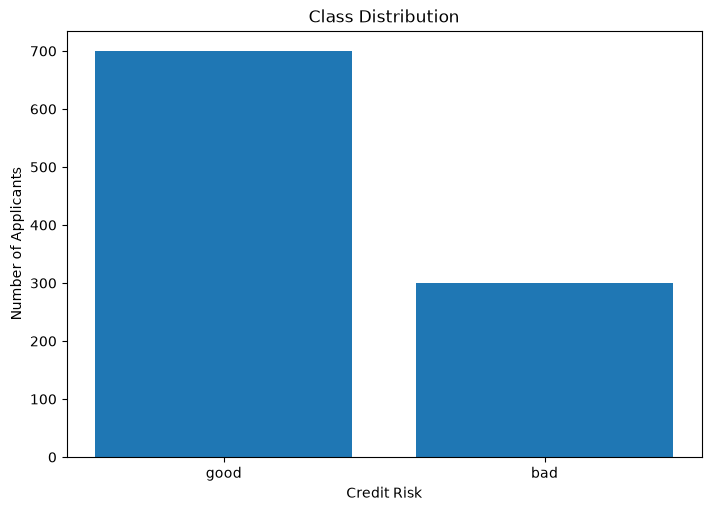

In [15]:
fig, ax = plt.subplots(figsize=(7, 5), layout="constrained")
class_counts = df["class"].value_counts()
ax.bar(class_counts.index, class_counts.values)
ax.set_title("Class Distribution")
ax.set_xlabel("Credit Risk")
ax.set_ylabel("Number of Applicants")
fig.savefig("graphs/image_1_class_distribution.png", dpi=150)
plt.show()


## According to Bar Chart

Imagine a model that predicts:

- GOOD
- GOOD
- GOOD
- GOOD
- GOOD

for every single applicant.
Because **70% of applicants are good**, that model would achieve approximately:
> **70% Accuracy**
But is it useful?
**No.**
It would never identify a **bad credit applicant**.
This teaches us an important lesson:
### Accuracy Alone Can Be Misleading
When the classes are imbalanced, a model can achieve high accuracy simply by predicting the majority class every time.


## The Fairness Problem

In [16]:
df["personal_status"].value_counts()

personal_status
male single           548
female div/dep/mar    310
male mar/wid           92
male div/sep           50
Name: count, dtype: int64

In [17]:
# Absolute count and proportion breakdown
counts = df["personal_status"].value_counts()
proportions = df["personal_status"].value_counts(normalize=True)

df_status_summary = pd.DataFrame({"count": counts, "share": proportions})
print(df_status_summary)

                    count  share
personal_status                 
male single           548  0.548
female div/dep/mar    310  0.310
male mar/wid           92  0.092
male div/sep           50  0.050


In [18]:
# Filter for female records with combined marital status
female_ambiguous_df = df[df["personal_status"] == "female div/dep/mar"]

print(f"Number of affected female rows: {len(female_ambiguous_df)}")
female_ambiguous_df.head()

Number of affected female rows: 310


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,2,real estate,22,none,own,1,skilled,1,none,yes,bad
10,0<=X<200,12,existing paid,new car,1295,<100,<1,3,female div/dep/mar,none,1,car,25,none,rent,1,skilled,1,none,yes,bad
11,<0,48,existing paid,business,4308,<100,<1,3,female div/dep/mar,none,4,life insurance,24,none,rent,1,skilled,1,none,yes,bad
12,0<=X<200,12,existing paid,radio/tv,1567,<100,1<=X<4,1,female div/dep/mar,none,1,car,22,none,own,1,skilled,1,yes,yes,good
14,<0,15,existing paid,new car,1403,<100,1<=X<4,2,female div/dep/mar,none,4,car,28,none,rent,1,skilled,1,none,yes,good



## 4. Feature engineering decisions

A few calls have to be made explicitly here rather than defaulted into.

**1. High-cardinality categoricals (`purpose`, `credit_history`, `checking_status`, `savings_status`, `employment`, `job`, `property_magnitude`, `other_payment_plans`, `housing`, `other_parties`, `own_telephone`, `foreign_worker`).**

These variables are kept as categorical features and will be one-hot encoded using `OneHotEncoder`. None of them have enough rare levels to clearly justify manual grouping. `purpose` is the closest case, with a few levels having single-digit counts, but collapsing these categories could remove useful information that tree-based models can use. Using one-hot encoding with `handle_unknown="ignore"` also allows rare or previously unseen categories to be handled safely.

The low-frequency categories are checked explicitly below rather than being grouped automatically.

**2. `personal_status`.**

The `personal_status` column combines sex and marital status into a single categorical value, such as `"male single"`, `"female div/dep/mar"`, `"male div/sep"`, and `"male mar/wid"`.

To make the feature structure more explicit, the column is split into two separate variables:

- `gender` — extracted from the first part of `personal_status`.
- `marital_status` — extracted from the remaining part.

For the modeling decision, `gender` is excluded from the model, while `marital_status` is retained. This allows the model to use potentially relevant marital-status information without directly using gender as a predictive feature.

After extracting the two variables, the original `personal_status` column and the derived `gender` column are dropped, leaving `marital_status` as the categorical feature used for modeling.

This is a deliberate modeling and fairness decision rather than an automatic preprocessing step. An alternative would be to drop `personal_status` entirely or to retain `gender` as a feature. The chosen approach allows the effect of excluding gender to be evaluated later through an ablation analysis.

## Cleaning Dataset

In [19]:
for col in ["checking_status","savings_status","employment"]:
    print(f"\n{col}")
    print(df[col].value_counts())


checking_status
checking_status
no checking    394
<0             274
0<=X<200       269
>=200           63
Name: count, dtype: int64

savings_status
savings_status
<100                603
no known savings    183
100<=X<500          103
500<=X<1000          63
>=1000               48
Name: count, dtype: int64

employment
employment
1<=X<4        339
>=7           253
4<=X<7        174
<1            172
unemployed     62
Name: count, dtype: int64


### Clean checking_status

In [20]:
checking_map = {"<0": "negative_balance","0<=X<200": "low_balance",">=200": "high_balance","no checking": "no_checking_account"}
df["checking_status"] = (df["checking_status"].cat.rename_categories(checking_map))
print(df["checking_status"])

0         negative_balance
1              low_balance
2      no_checking_account
3         negative_balance
4         negative_balance
              ...         
995    no_checking_account
996       negative_balance
997    no_checking_account
998       negative_balance
999            low_balance
Name: checking_status, Length: 1000, dtype: category
Categories (4, str): ['low_balance', 'negative_balance', 'high_balance', 'no_checking_account']


### Clean savings_status

In [21]:
savings_map = {"<100": "low_savings","100<=X<500": "lower_medium_savings","500<=X<1000": "upper_medium_savings",">=1000": "high_savings","no known savings": "unknown_savings"}
df["savings_status"] = (df["savings_status"].cat.rename_categories(savings_map))
print(df["savings_status"])

0           unknown_savings
1               low_savings
2               low_savings
3               low_savings
4               low_savings
               ...         
995             low_savings
996             low_savings
997             low_savings
998             low_savings
999    lower_medium_savings
Name: savings_status, Length: 1000, dtype: category
Categories (5, str): ['lower_medium_savings', 'upper_medium_savings', 'low_savings', 'high_savings', 'unknown_savings']


In [22]:
savings_counts = df["savings_status"].value_counts()
print(savings_counts)

savings_status
low_savings             603
unknown_savings         183
lower_medium_savings    103
upper_medium_savings     63
high_savings             48
Name: count, dtype: int64


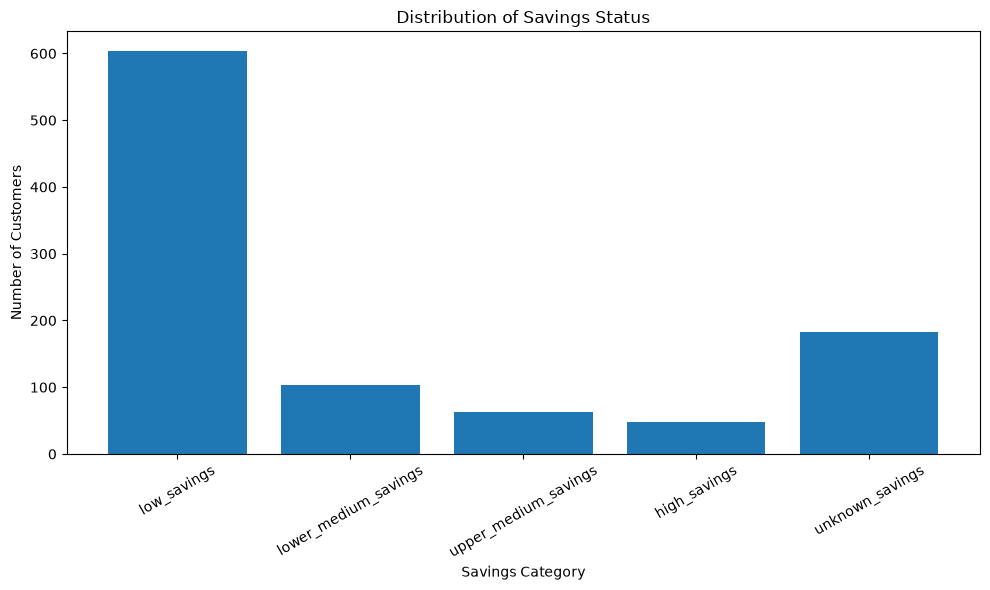

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

counts = df["savings_status"].value_counts()

order = [
    "low_savings",
    "lower_medium_savings",
    "upper_medium_savings",
    "high_savings",
    "unknown_savings"
]

counts = counts.reindex(order, fill_value=0)

ax.bar(counts.index, counts.values)

ax.set_title("Distribution of Savings Status")
ax.set_xlabel("Savings Category")
ax.set_ylabel("Number of Customers")
ax.tick_params(axis="x", rotation=30)

fig.tight_layout()
fig.savefig("graphs/image_2_savings_status.png", dpi=150)
plt.show()


### Clean employment

In [24]:
employment_map = {
    "unemployed": "unemployed",
    "<1": "less_than_1_year",
    "1<=X<4": "one_to_four_years",
    "4<=X<7": "four_to_seven_years",
    ">=7": "seven_or_more_years"
}

df["employment"] = df["employment"].cat.rename_categories(employment_map)
print(df["employment"])

0      seven_or_more_years
1        one_to_four_years
2      four_to_seven_years
3      four_to_seven_years
4        one_to_four_years
              ...         
995    four_to_seven_years
996      one_to_four_years
997    seven_or_more_years
998      one_to_four_years
999             unemployed
Name: employment, Length: 1000, dtype: category
Categories (5, str): ['one_to_four_years', 'four_to_seven_years', 'less_than_1_year', 'seven_or_more_years', 'unemployed']


In [25]:
employment_counts = df["employment"].value_counts()
print(employment_counts)

employment
one_to_four_years      339
seven_or_more_years    253
four_to_seven_years    174
less_than_1_year       172
unemployed              62
Name: count, dtype: int64


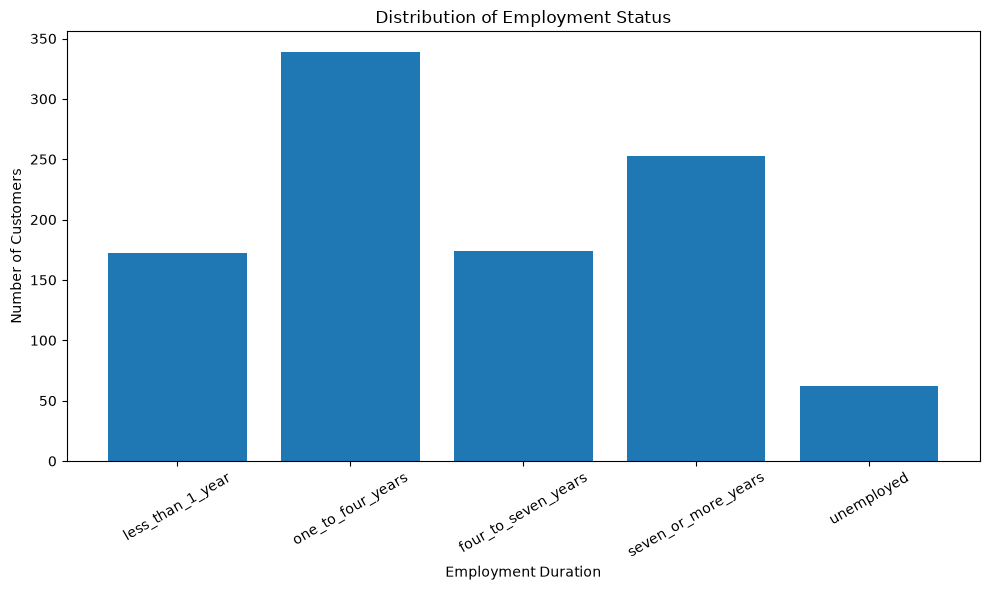

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))
counts = df["employment"].value_counts()
order = [
    "less_than_1_year",
    "one_to_four_years",
    "four_to_seven_years",
    "seven_or_more_years",
    "unemployed"
]
counts = counts.reindex(order, fill_value=0)
ax.bar(counts.index, counts.values)
ax.set_title("Distribution of Employment Status")
ax.set_xlabel("Employment Duration")
ax.set_ylabel("Number of Customers")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
fig.savefig("graphs/image_3_employment.png", dpi=150)
plt.show()


In [27]:
print("\n" + "=" * 50)
print("Info:\n",df.info())
print("\n" + "=" * 50)
print("Missing Values:\n",df.isna().sum())
print("\n" + "=" * 50)
print("Duplicate: ",df.duplicated().sum())


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   checking_status         1000 non-null   category
 1   duration                1000 non-null   int64   
 2   credit_history          1000 non-null   category
 3   purpose                 1000 non-null   category
 4   credit_amount           1000 non-null   int64   
 5   savings_status          1000 non-null   category
 6   employment              1000 non-null   category
 7   installment_commitment  1000 non-null   int64   
 8   personal_status         1000 non-null   category
 9   other_parties           1000 non-null   category
 10  residence_since         1000 non-null   int64   
 11  property_magnitude      1000 non-null   category
 12  age                     1000 non-null   int64   
 13  other_payment_plans     1000 non-null   category
 14  housing                 1000 non-nu

### Corrected personal_status

#### Gender Column

In [28]:
df["gender"] = df["personal_status"].astype(str).str.split().str[0]
print(df["gender"].value_counts())
print(df[["personal_status", "gender"]].head(10))


gender
male      690
female    310
Name: count, dtype: int64
      personal_status  gender
0         male single    male
1  female div/dep/mar  female
2         male single    male
3         male single    male
4         male single    male
5         male single    male
6         male single    male
7         male single    male
8        male div/sep    male
9        male mar/wid    male


#### marital_status Column

In [29]:
marital_map = {
    "male single": "single",
    "male mar/wid": "married_or_widowed",
    "male div/sep": "divorced_or_separated",
    "female div/dep/mar": "divorced_or_dependent_or_married"
}

df["marital_status"] = df["personal_status"].map(marital_map)
print(df["marital_status"].value_counts())
print(df[["personal_status", "gender","marital_status"]].head(10))

marital_status
single                              548
divorced_or_dependent_or_married    310
married_or_widowed                   92
divorced_or_separated                50
Name: count, dtype: int64
      personal_status  gender                    marital_status
0         male single    male                            single
1  female div/dep/mar  female  divorced_or_dependent_or_married
2         male single    male                            single
3         male single    male                            single
4         male single    male                            single
5         male single    male                            single
6         male single    male                            single
7         male single    male                            single
8        male div/sep    male             divorced_or_separated
9        male mar/wid    male                married_or_widowed


In [30]:
df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class,gender,marital_status
0,negative_balance,6,critical/other existing credit,radio/tv,1169,unknown_savings,seven_or_more_years,4,male single,none,4,real estate,67,none,own,2,skilled,1,yes,yes,good,male,single
1,low_balance,48,existing paid,radio/tv,5951,low_savings,one_to_four_years,2,female div/dep/mar,none,2,real estate,22,none,own,1,skilled,1,none,yes,bad,female,divorced_or_dependent_or_married
2,no_checking_account,12,critical/other existing credit,education,2096,low_savings,four_to_seven_years,2,male single,none,3,real estate,49,none,own,1,unskilled resident,2,none,yes,good,male,single
3,negative_balance,42,existing paid,furniture/equipment,7882,low_savings,four_to_seven_years,2,male single,guarantor,4,life insurance,45,none,for free,1,skilled,2,none,yes,good,male,single
4,negative_balance,24,delayed previously,new car,4870,low_savings,one_to_four_years,3,male single,none,4,no known property,53,none,for free,2,skilled,2,none,yes,bad,male,single


## 5. Train/test split, baseline, and preprocessing pipeline

Stratifying on the target since the classes are imbalanced -- an un-stratified
split could easily skew the 30% "bad" class further in a 1,000-row dataset.


In [31]:
# build the modeling frame: drop personal_status (replaced) and sex (excluded on purpose)
model_df = df.drop(columns=["personal_status","gender"])

target = (model_df["class"] == "bad").astype(int)  # 1 = bad credit risk
features = model_df.drop(columns=["class"])

categorical_features = features.select_dtypes(exclude="number").columns.tolist()
numeric_features = features.select_dtypes(include="number").columns.tolist()

# Force plain string dtype on every categorical column. fetch_openml can hand back
# pandas `category` dtype, and how OneHotEncoder infers categories from a
# `category`-dtype column vs. a plain string column is NOT identical across
# sklearn/pandas versions -- this has caused real train/test column-count
# mismatches. Casting to str removes that ambiguity entirely.
features[categorical_features] = features[categorical_features].astype(str)

print("categorical:", categorical_features)
print("numeric:", numeric_features)

categorical: ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker', 'marital_status']
numeric: ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']


In [32]:
pd.crosstab(df["gender"], df["class"])

class,bad,good
gender,,
female,109,201
male,191,499


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, stratify=target, random_state=RANDOM_STATE
)

print(X_train.shape, X_test.shape)
print("train class balance:\n", y_train.value_counts(normalize=True))
print("test class balance:\n", y_test.value_counts(normalize=True))

(800, 20) (200, 20)
train class balance:
 class
0    0.7
1    0.3
Name: proportion, dtype: float64
test class balance:
 class
0    0.7
1    0.3
Name: proportion, dtype: float64


In [34]:
# baseline: always predict the majority class ("good" -> 0)
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

print("baseline accuracy:", accuracy_score(y_test, baseline_pred))
# with 70/30 imbalance, accuracy alone is a weak yardstick -- precision/recall/F1
# on the minority ("bad") class matter more, since baseline recall on "bad" is 0
print("baseline recall on 'bad':", recall_score(y_test, baseline_pred))


baseline accuracy: 0.7
baseline recall on 'bad': 0.0


In [35]:
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features),
    ]
)


## 6. Models: logistic regression + random forest

`class_weight="balanced"` is used on both so the 70/30 imbalance doesn't just
get absorbed into "always predict good" -- worth comparing against
unweighted versions if you want to see the difference imbalance handling makes.


In [36]:
models = {
    "logistic_regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "random_forest": RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE, class_weight="balanced"
    ),
}

fitted = {}
results = []

for name, clf in models.items():
    pipe = Pipeline([("preprocess", preprocess), ("clf", clf)])
    pipe.fit(X_train, y_train)
    fitted[name] = pipe

    # sanity check: the fitted preprocessor must produce the same number of
    # columns for train and test. If this ever fails, something upstream
    # (stale kernel state, a dtype mismatch) needs fixing before trusting
    # any metric below.
    n_train_cols = pipe.named_steps["preprocess"].transform(X_train).shape[1]
    n_test_cols = pipe.named_steps["preprocess"].transform(X_test).shape[1]
    assert n_train_cols == n_test_cols, (
        f"{name}: preprocessing produced {n_train_cols} train columns "
        f"but {n_test_cols} test columns"
    )

    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]

    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision_bad": precision_score(y_test, pred),
        "recall_bad": recall_score(y_test, pred),
        "f1_bad": f1_score(y_test, pred),
        "roc_auc": roc_auc_score(y_test, proba),
    })

results_df = pd.DataFrame(results).set_index("model")
results_df


,accuracy,precision_bad,recall_bad,f1_bad,roc_auc
model,,,,,
logistic_regression,0.75,0.558140,0.800000,0.657534,0.805833
random_forest,0.77,0.616667,0.616667,0.616667,0.802143


In [37]:
results_df.loc["baseline"] = {
    "accuracy": accuracy_score(y_test, baseline_pred),
    "precision_bad": precision_score(y_test, baseline_pred, zero_division=0),
    "recall_bad": recall_score(y_test, baseline_pred, zero_division=0),
    "f1_bad": f1_score(y_test, baseline_pred, zero_division=0),
    "roc_auc": np.nan,  # baseline gives no probabilities worth scoring
}
results_df.sort_values("roc_auc", ascending=False)

,accuracy,precision_bad,recall_bad,f1_bad,roc_auc
model,,,,,
logistic_regression,0.75,0.558140,0.800000,0.657534,0.805833
random_forest,0.77,0.616667,0.616667,0.616667,0.802143
baseline,0.70,0.000000,0.000000,0.000000,NaN


## 7. Ablation: does dropping `gender` actually cost anything?

Refit both models with `gender` included, to see whether excluding it (the
decision made in section 4) had a real performance cost or was close to free.


In [38]:
# Create an explicit copy so global model_df is not altered
features_with_gender = df.drop(columns=["class", "personal_status"]).copy()

cat_with_gender = features_with_gender.select_dtypes(exclude="number").columns.tolist()
num_with_gender = features_with_gender.select_dtypes(include="number").columns.tolist()
features_with_gender[cat_with_gender] = features_with_gender[cat_with_gender].astype(str)

Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    features_with_gender, target, test_size=0.2, stratify=target, random_state=RANDOM_STATE
)

preprocess_gender = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_with_gender),
    ("num", StandardScaler(), num_with_gender),
])

ablation = []
for name, clf in models.items():
    # Clone the classifier so the original estimator in fitted/models isn't overwritten
    pipe_ablation = Pipeline([("preprocess", preprocess_gender), ("clf", clone(clf))])
    pipe_ablation.fit(Xs_train, ys_train)
    proba = pipe_ablation.predict_proba(Xs_test)[:, 1]
    ablation.append({"model": f"{name}_with_gender", "roc_auc": roc_auc_score(ys_test, proba)})

pd.DataFrame(ablation).set_index("model")

,roc_auc
model,
logistic_regression_with_gender,0.805833
random_forest_with_gender,0.802321


## 8. Error analysis

Look at the random forest's actual mistakes (swap in `logistic_regression`
below to compare). In a lending context, a false negative -- predicting
"good" when the applicant is actually "bad" -- is typically the costlier
mistake, so it's worth checking whether errors skew that direction.


In [39]:
# Identify best model excluding baseline
best_name = results_df.drop("baseline").sort_values("roc_auc", ascending=False).index[0]
best_pipe = fitted[best_name]

# Generate predictions using the properly fitted pipeline on original X_test
best_pred = best_pipe.predict(X_test)
best_proba = best_pipe.predict_proba(X_test)[:, 1]

print("best model by ROC-AUC:", best_name)
print(classification_report(y_test, best_pred, target_names=["good", "bad"]))

best model by ROC-AUC: logistic_regression
              precision    recall  f1-score   support

        good       0.89      0.73      0.80       140
         bad       0.56      0.80      0.66        60

    accuracy                           0.75       200
   macro avg       0.73      0.76      0.73       200
weighted avg       0.79      0.75      0.76       200



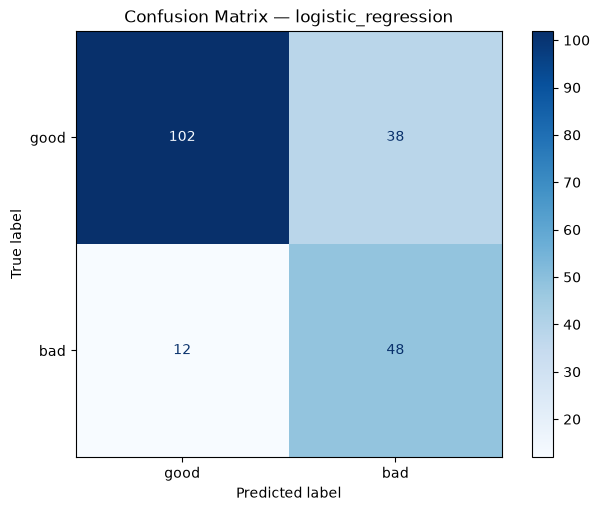

In [40]:

cm = confusion_matrix(y_test, best_pred)

fig, ax = plt.subplots(figsize=(7, 5), layout="constrained")

disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["good", "bad"])
disp.plot(cmap="Blues", ax=ax)
ax.set_title(f"Confusion Matrix — {best_name}")
fig.savefig(f"graphs/image_4_confusion_matrix_{best_name}.png",dpi=150,bbox_inches="tight")
plt.show()

In [41]:
errors = X_test.copy()
errors["true"] = y_test
errors["pred"] = best_pred
errors["pred_proba_bad"] = best_proba

false_negatives = errors[(errors["true"] == 1) & (errors["pred"] == 0)]
false_positives = errors[(errors["true"] == 0) & (errors["pred"] == 1)]

print(f"false negatives (actually bad, predicted good): {len(false_negatives)}")
print(f"false positives (actually good, predicted bad): {len(false_positives)}")


false negatives (actually bad, predicted good): 12
false positives (actually good, predicted bad): 38


In [42]:
# what distinguishes the false negatives from correctly-caught 'bad' cases?
true_positives = errors[(errors["true"] == 1) & (errors["pred"] == 1)]

compare_cols = ["duration", "credit_amount", "age"]
pd.concat({
    "false_negatives (missed)": false_negatives[compare_cols].mean(),
    "true_positives (caught)": true_positives[compare_cols].mean(),
}, axis=1)


,false_negatives (missed),true_positives (caught)
duration,14.916667,29.187500
credit_amount,3494.333333,4959.770833
age,32.416667,32.416667


In [43]:
# cases the model was most confidently wrong about -- worth reading individually
errors["abs_error_confidence"] = (errors["true"] - errors["pred_proba_bad"]).abs()
errors.sort_values("abs_error_confidence", ascending=False).head(10)


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,marital_status,true,pred,pred_proba_bad,abs_error_confidence
818,negative_balance,36,existing paid,other,15857,low_savings,unemployed,2,co applicant,3,car,43,none,own,1,high qualif/self emp/mgmt,1,none,yes,divorced_or_separated,0,1,0.966264,0.966264
190,no_checking_account,24,existing paid,business,4591,high_savings,one_to_four_years,2,none,3,life insurance,54,none,own,3,high qualif/self emp/mgmt,1,yes,yes,single,1,0,0.057457,0.942543
229,negative_balance,24,existing paid,furniture/equipment,3149,low_savings,less_than_1_year,4,none,1,no known property,22,bank,for free,1,skilled,1,none,yes,single,0,1,0.931862,0.931862
395,low_balance,39,delayed previously,education,11760,lower_medium_savings,four_to_seven_years,2,none,3,no known property,32,none,rent,1,skilled,1,yes,yes,single,0,1,0.920840,0.920840
796,negative_balance,18,existing paid,used car,7511,unknown_savings,seven_or_more_years,1,none,4,life insurance,51,none,for free,1,skilled,2,yes,yes,single,1,0,0.102872,0.897128
141,low_balance,36,existing paid,radio/tv,4795,low_savings,less_than_1_year,4,none,1,no known property,30,none,own,1,high qualif/self emp/mgmt,1,yes,yes,divorced_or_dependent_or_married,0,1,0.896524,0.896524
228,no_checking_account,9,existing paid,radio/tv,1478,low_savings,four_to_seven_years,4,none,2,car,22,none,own,1,skilled,1,none,yes,single,1,0,0.119143,0.880857
221,negative_balance,12,existing paid,education,1200,unknown_savings,one_to_four_years,4,none,4,life insurance,23,bank,rent,1,skilled,1,yes,yes,divorced_or_dependent_or_married,0,1,0.872574,0.872574
435,low_balance,12,existing paid,radio/tv,1484,unknown_savings,one_to_four_years,2,none,1,real estate,25,none,own,1,skilled,1,yes,yes,married_or_widowed,1,0,0.134765,0.865235
746,negative_balance,15,existing paid,new car,2511,low_savings,unemployed,1,none,4,car,23,none,rent,1,skilled,1,none,yes,divorced_or_dependent_or_married,0,1,0.837892,0.837892


## 9. Calibration

Do the predicted probabilities mean what they claim to mean? A model can
have a strong ROC-AUC (good at ranking) while still being poorly calibrated
(its "70% chance of bad" isn't really a 70% empirical rate).


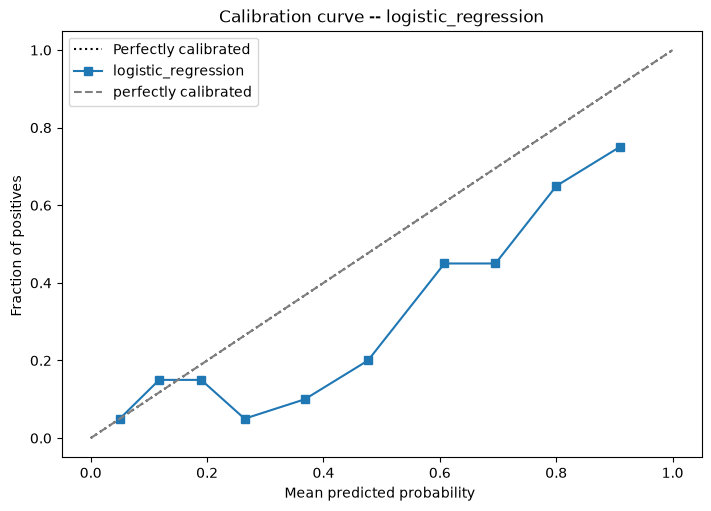

Brier score: 0.18242132865458166


In [44]:
frac_pos, mean_pred = calibration_curve(y_test, best_proba, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(7, 5), layout="constrained")
CalibrationDisplay(prob_true=frac_pos, prob_pred=mean_pred, y_prob=best_proba).plot(ax=ax, name=best_name)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="perfectly calibrated")
ax.set_title(f"Calibration curve -- {best_name}")
ax.legend()
safe_name = best_name.lower().replace(" ", "_")
fig.savefig(
    f"graphs/image_5_calibration_curve_{safe_name}.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

print("Brier score:", brier_score_loss(y_test, best_proba))


A Brier score close to 0 and a curve hugging the diagonal both indicate
well-calibrated probabilities. Random forests are often *overconfident* near
the extremes on datasets this size (few hundred test rows) since individual
trees can produce very confident, noisy votes -- worth checking whether that
shows up here, and whether `CalibratedClassifierCV` would be worth adding
before trusting these probabilities for anything beyond ranking.


## 10. Reflection
Working with the German Credit dataset was different from working with the synthetic datasets because the structure and relationships in the data were not designed to produce a controlled or obvious answer. The dataset did not contain missing values or duplicate rows, but the main challenge was understanding the large number of categorical variables and deciding how they should be represented for machine learning.

One of the most important observations was the class imbalance. Since approximately 70% of the applicants belong to the good credit class, a simple majority-class baseline can achieve around 70% accuracy without identifying any bad credit applicants. This demonstrated why accuracy alone is not sufficient for evaluating a classification model. Precision, recall, F1-score, and ROC-AUC provided a more complete picture of model performance, especially for detecting bad credit risks.

Another important difference was the need to make an explicit feature-engineering and ethical decision about the personal_status feature. Because this column combines marital status and gender-related information, I chose to exclude it from the model to reduce the possibility of using sensitive demographic information in a credit-risk decision. This showed that working with real-world data requires considering not only technical model performance but also fairness and the potential consequences of using particular features.

Overall, the experience showed that the machine learning pipeline learned from synthetic datasets still applies to real data, including train/test splitting, preprocessing pipelines, baselines, model comparison, error analysis, and calibration. However, real datasets require more judgment. Instead of simply finding a known pattern or beating a controlled baseline, I had to understand the data, make decisions about features, interpret model mistakes, and consider whether the predictions would be appropriate for a real-world decision-making system.
